# Value Based Segmentation for Amazing International Airlines Inc
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----
# Exploratory Data Analysis (EDA) 
## Summary

Value-based segmentation, grouping customers according to their economic contribution.

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#0-bullet)<br>

[**Metadata**](#1-bullet)<br>

[**Data Preprocessing**](#1st-bullet)<br>
- [**Inconcistances**](#2nd-bullet)<br>
- [**Outliers**](#2nd-bullet)<br>
- [**Scaling**](#1st-bullet)<br>
    - [Robust Scaler](#3rd-bullet)<br>

[**Clustering**](#1st-bullet)<br>
- [**KNN**](#2nd-bullet)<br>
- [**KNN**](#2nd-bullet)<br>

    
</div>

<a class="anchor" id="0-bullet">    </a>
## Imports
[Back to Index](#toc)

In [383]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
sns.set_context("notebook")
sns.set_style("ticks")

In [384]:
MasterCustomerDB_Complete = pd.read_csv('../../data/DM_AIAI_MasterCustomerDB.csv')
MasterCustomerDB = MasterCustomerDB_Complete.copy()

In [385]:
cols_to_keep = [
    'Loyalty#',
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

Value_Based_Segmentation_clustering = MasterCustomerDB[cols_to_keep].copy()
Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.set_index('Loyalty#')

<a class="anchor" id="value-based-segmentation">    </a>
## Metadata – Value-Based Segmentation
[Back to Index](#toc)

**Preprocessed & Merged Dataset**

*This dataset is derived from the integration and transformation of `DM_AIAI_CustomerDB.csv` and `DM_AIAI_FlightsDB.csv`.  
It contains engineered features designed to support value-based customer segmentation, focusing on customer profitability, loyalty behavior, and engagement over time.*

### Variables

- *Customer Lifetime Value* – Total estimated monetary value generated by the customer over the duration of the relationship

- *Days_with_us* – Total number of days the customer has been active in the loyalty program since enrollment

- *Days_until_reengagement* – Number of days between cancellation and re-engagement for returning customers

- *Total_NumFlights* – Total number of flights taken by the customer during the observed period

- *Total_DistanceKM* – Total cumulative flight distance traveled by the customer in kilometers

- *Perc_Flights_With_Companions* – Percentage of flights taken with companions relative to the customer’s total flights

- *Dollar_Cost_Points_Remaining* – Estimated dollar value of loyalty points accumulated but not yet redeemed by the customer

- *Recency_Days* – Number of days since the customer’s most recent flight activity


# Preprocessing

Lets explore our EDA data set on NA and negativenumbers

In [386]:
Value_Based_Segmentation_clustering.isna().sum()


Customer Lifetime Value             0
Days_with_us                        0
Days_until_reengagement         16373
Total_NumFlights                 1471
Total_DistanceKM                 1471
Perc_Flights_With_Companions     1471
Dollar_Cost_Points_Remaining     1471
Recency_Days                     1471
dtype: int64

In [387]:
(Value_Based_Segmentation_clustering < 0).sum()

Customer Lifetime Value           0
Days_with_us                      0
Days_until_reengagement           0
Total_NumFlights                  0
Total_DistanceKM                  0
Perc_Flights_With_Companions      0
Dollar_Cost_Points_Remaining    481
Recency_Days                      0
dtype: int64

### Data Cleaning Steps

We proceed step by step with the data preparation:

1. **Days Until Re-engagement**  
   - `Days_until_reengagement` has **16,373 missing values**.  
   - These missing values correspond to customers who **did not leave the program**.  
   - We therefore impute these missing values with **0**.

2. **Value-Based Transaction Features**  
   - The following variables contain **1,471 missing values**:  
     - `Total_NumFlights`  
     - `Total_DistanceKM`  
     - `Dollar_Cost_Points_Remaining`  
     - `Recency_Days`  
   - These missing values indicate customers who **have not made any transactions**.  
   - Instead of imputing, we isolate these observations into a separate cluster labeled **“No Transaction”**.

3. **Negative Point Balances**  
   - There are **481 observations** with negative values in `Dollar_Cost_Points_Remaining`.  
   - Since it is not meaningful for a customer to redeem more points than they have earned,  
     we apply a **lower bound (floor) of 0** to this variable.


Identify “No Transaction” customers

In [388]:
transaction_cols = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]
no_transaction_mask = Value_Based_Segmentation_clustering[transaction_cols].isna().any(axis=1)
Value_Based_Segmentation_clustering_no_transaction = Value_Based_Segmentation_clustering[no_transaction_mask].copy()


Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.dropna(subset=transaction_cols)

Value_Based_Segmentation_clustering_no_transaction.shape[0]


1471

Days_until_reengagement → impute with 0

In [389]:
Value_Based_Segmentation_clustering['Days_until_reengagement'] = (
    Value_Based_Segmentation_clustering['Days_until_reengagement']
    .fillna(0)
)

Negative Dollar_Cost_Points_Remaining → floor at 0

In [390]:
Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining'] = (
    Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining']
    .clip(lower=0)
)

Quick sanity checks

In [391]:
# Check remaining missing values
print(Value_Based_Segmentation_clustering.isna().sum())

# Check negative values
print((Value_Based_Segmentation_clustering < 0).sum())
# Check transaction group sizes
print(Value_Based_Segmentation_clustering_no_transaction.shape[0])


Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
1471


## Visualisation

### Extreme Outlier Reference (3×IQR)

In addition to standard boxplots, we include a visual reference for *extreme outliers* using the **3× interquartile range (IQR)** rule.

While the conventional 1.5×IQR threshold highlights moderately unusual observations, the 3×IQR threshold identifies values that are *extremely distant* from the central distribution.

Importantly, these thresholds are **not used for automatic removal**.  
They are included solely as a diagnostic and interpretative tool to support exploratory data analysis and to assess whether certain variables contain values that may disproportionately influence visualization or downstream modeling.

Extreme outlier boundaries are displayed only when such values are present in the data.


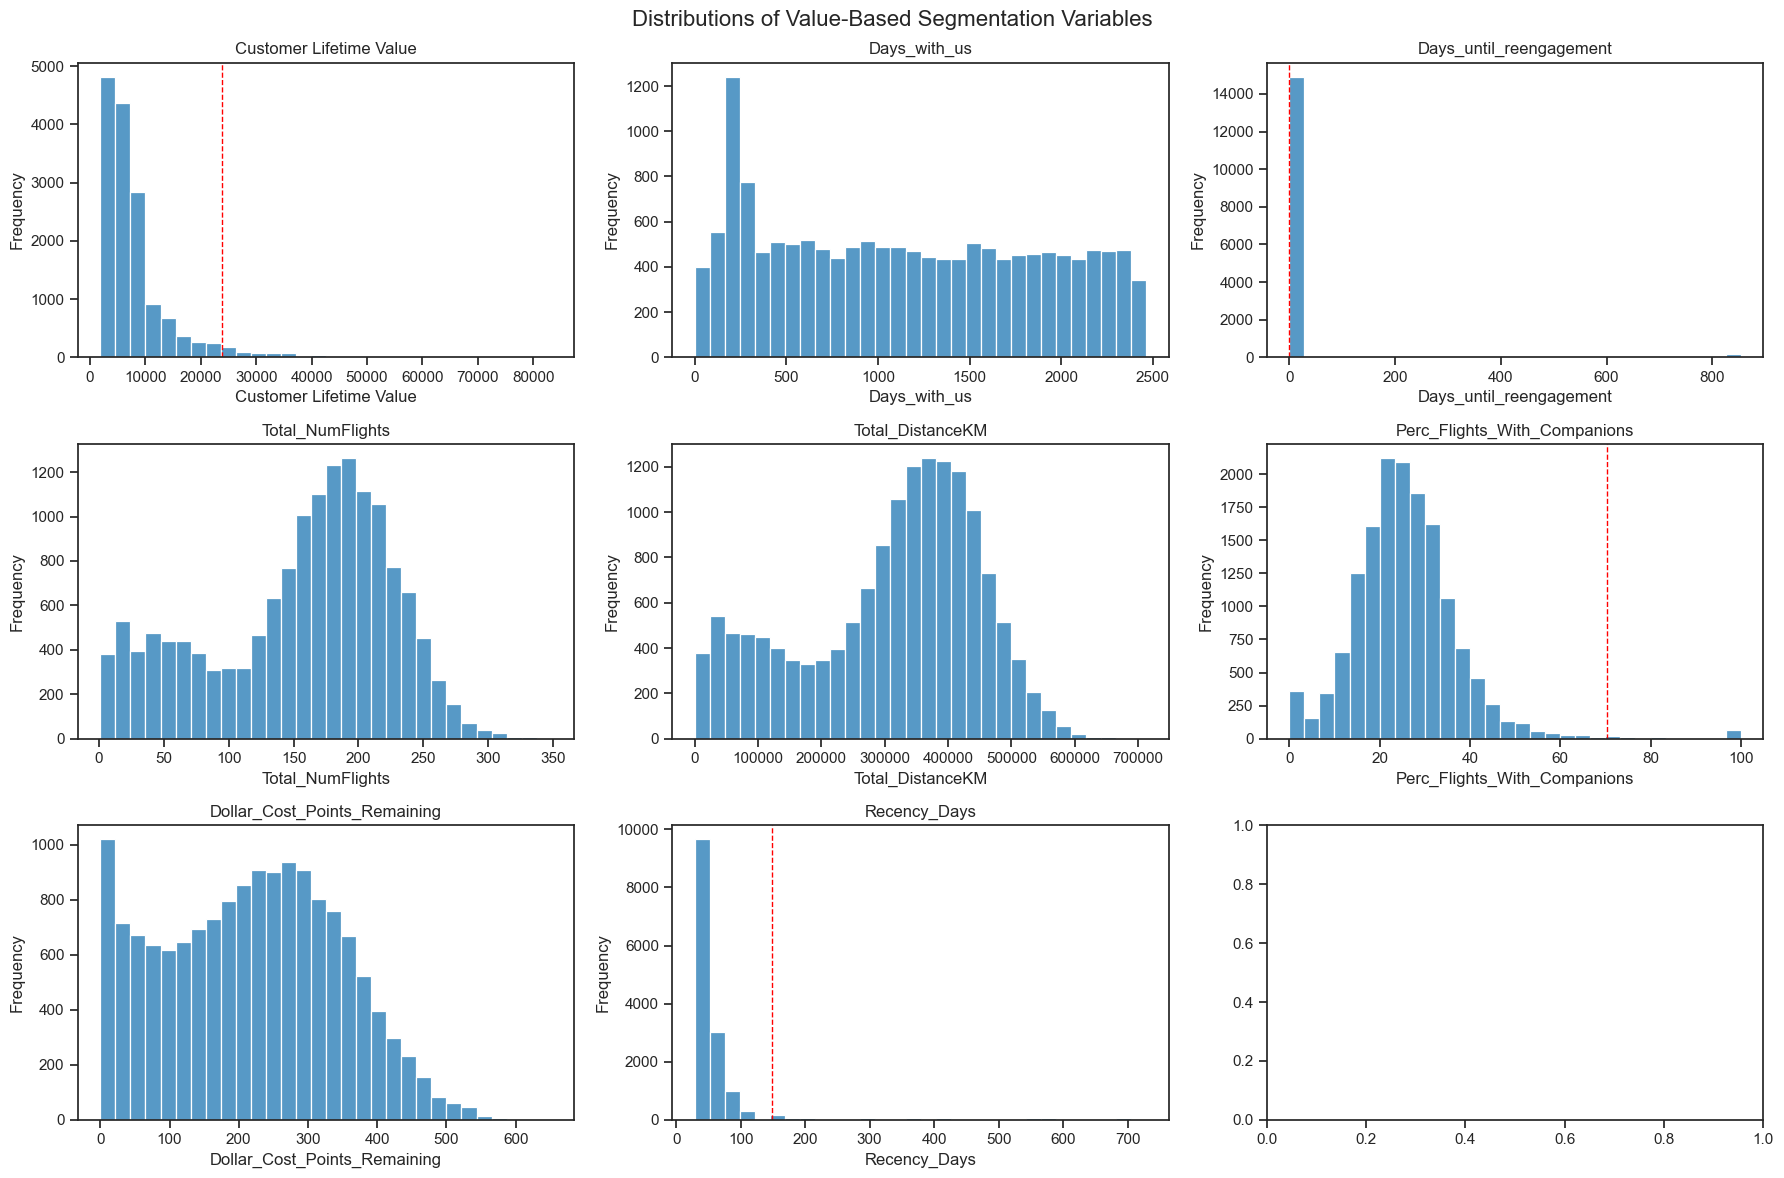

In [392]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    data = Value_Based_Segmentation_clustering[col].dropna()

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Value-Based Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()
# ...existing code...

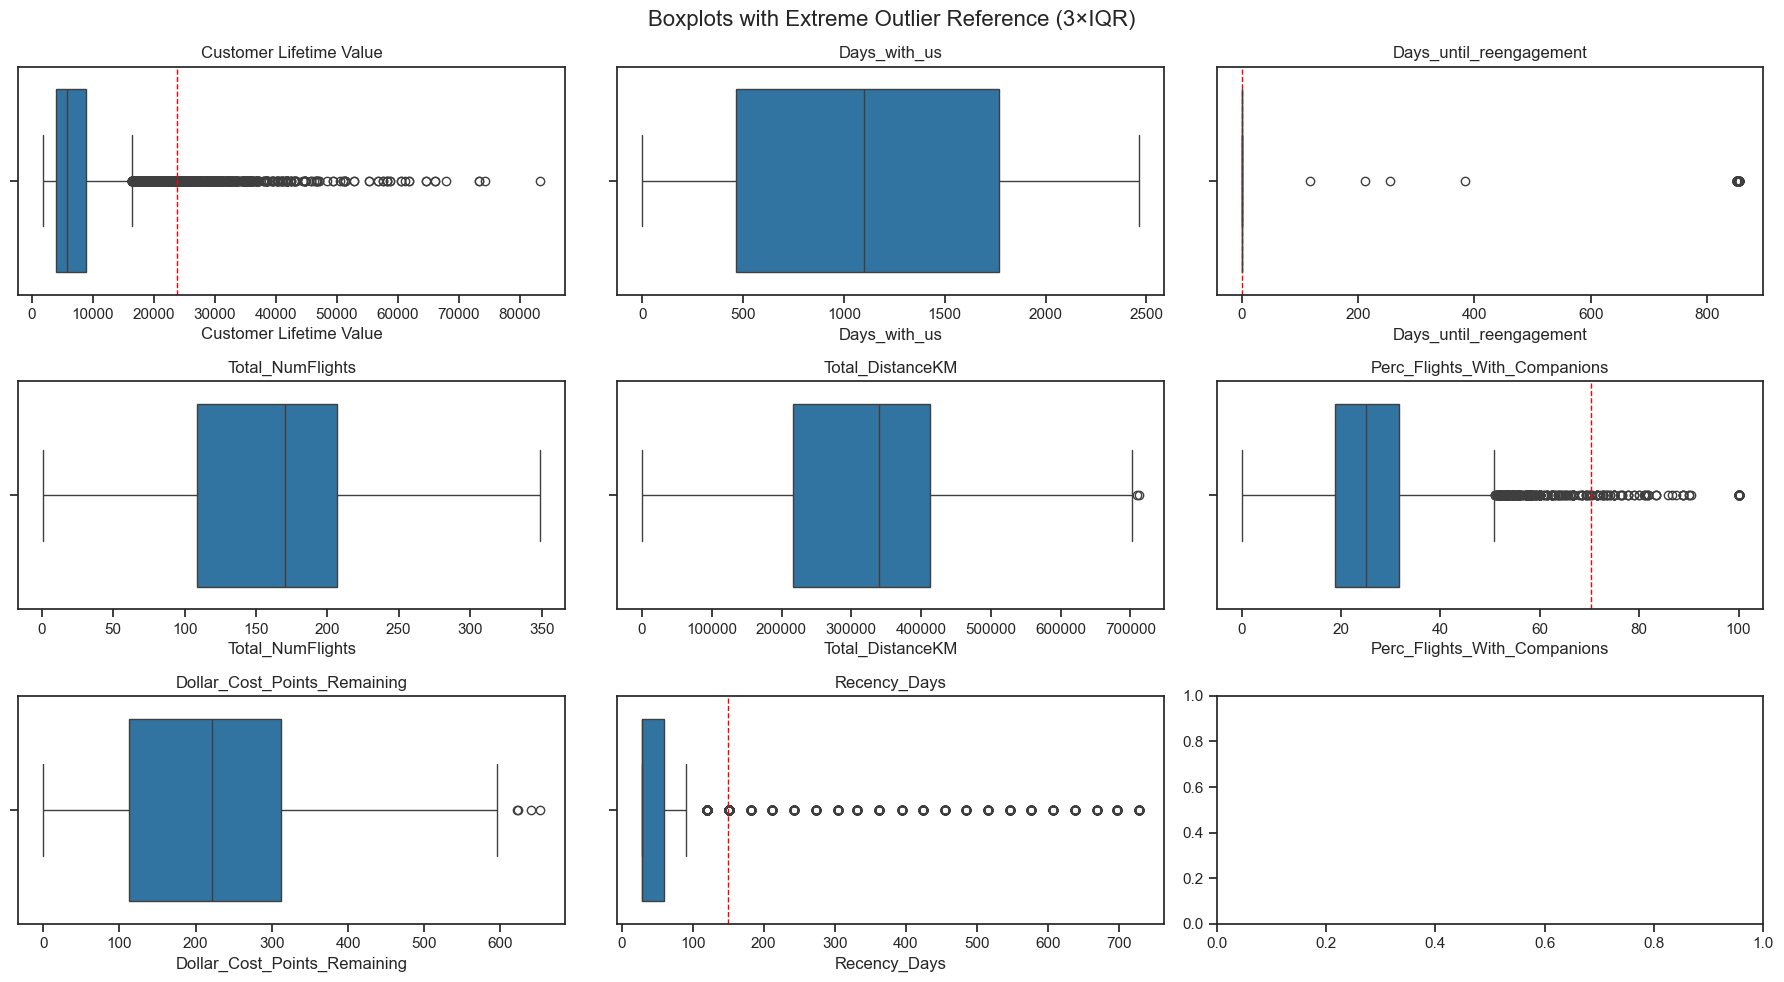

In [393]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()


Overall, the graphs look acceptable. There is some right skewness, but it does not appear to be a major issue at this stage.</br></br>
The main parameters that require closer inspection are Customer Lifetime Value, Days Until, Percentage of Flights with Companions, and Recency Days Reengagement. We analyze these features one by one to understand whether the extreme values represent true outliers or meaningful customer behavior. This assessment will help decide whether they should be preserved for clustering or handled during the scaling step.

## Outliers Detection

### Customer Lifetime Value

Customer Lifetime Value is a core variable in value-based segmentation. Extremely high values may indicate highly valuable customers rather than noise, so they should not be removed without careful consideration.
To better understand the distribution, we examine the proportion of customers with a lifetime value above 60,000. This helps undertand whether these values are rare outliers or represent a meaningful segment in the data.

In [394]:
clv = Value_Based_Segmentation_clustering['Customer Lifetime Value']
Q1 = clv.quantile(0.25)
Q3 = clv.quantile(0.75)
IQR = Q3 - Q1

clv_upper_3iqr = Q3 + 3 * IQR

clv_perc_above_3iqr = (clv > clv_upper_3iqr).mean() * 100

clv_perc_above_3iqr


np.float64(3.8275610886696247)

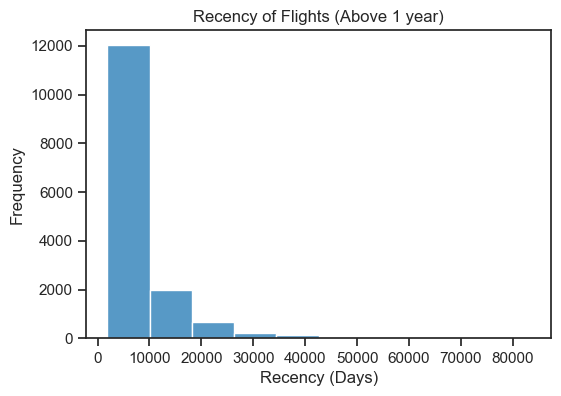

In [395]:
plt.figure(figsize=(6,4))
sns.histplot(clv[clv > clv_perc_above_3iqr], bins=10)
plt.title("Recency of Flights (Above 1 year)")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.show()

The percentage of extreme values is very small, and since these customers remain high-value, we will apply a ceiling to limit values above three times the upper quartile. This helps reduce the impact of extremes and can potentially improve clustering results.

In [396]:
Value_Based_Segmentation_clustering['Customer Lifetime Value'] = (
    Value_Based_Segmentation_clustering['Customer Lifetime Value']
    .clip(upper=clv_upper_3iqr)
)

In [397]:
print(Value_Based_Segmentation_clustering['Customer Lifetime Value'].max() == clv_upper_3iqr)

True


### Days until reengagement

This variable contains a large number of zeros, which correspond to customers who never left the program. In this case, standard outlier detection methods such as IQR are not informative.
To better understand the behavior of this feature, we analyze its distribution after excluding active users. This allows us to focus on customers who actually disengaged and observe how reengagement time is distributed.

98.82127011456195


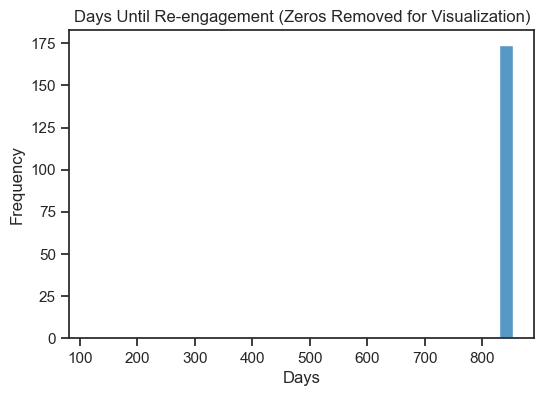

In [398]:
dur = Value_Based_Segmentation_clustering['Days_until_reengagement']

# Percentage of zeros
perc_zero = (dur == 0).mean() * 100
print(perc_zero)
plt.figure(figsize=(6,4))
sns.histplot(dur[dur > 0], bins=30)
plt.title("Days Until Re-engagement (Zeros Removed for Visualization)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()


In [399]:
perc_800= (dur > 800).mean() * 100
print(perc_800)
print(perc_800 + perc_zero)

1.1522415734057347
99.97351168796769


A small fraction of customers (around 2%) shows extremely long re-engagement periods, in some cases exceeding 800 days. These customers typically flew with us, left the program, and rejoined after a long gap(for example due to promotion).
Although these values are extreme compared to the rest of the dataset, they reflect real customer behavior rather than noise. To avoid distorting clustering distances.

Based on this, we consider this approache: We will apply scaling methods that account for these differences and evaluate how they affect the clustering results.

### Percentage of Flights With Companions

This feature presents a situation similar to Customer Lifetime Value. While extreme values exist, they may reflect meaningful travel behavior rather than noise.
Before moving forward, it is important to examine how the data behaves at the extremes of this variable. Since this feature is essential for clustering, the decision on how to handle these values should be made carefully, balancing robustness with the need to preserve relevant customer patterns.

0.8343818290179458


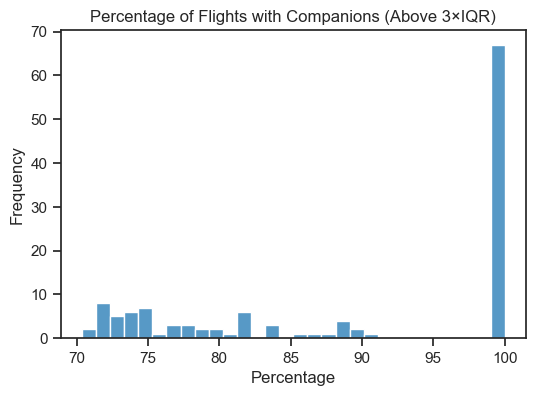

In [400]:
companions = Value_Based_Segmentation_clustering['Perc_Flights_With_Companions']
Q1 = companions.quantile(0.25)
Q3 = companions.quantile(0.75)
IQR = Q3 - Q1

companions_upper_3iqr = Q3 + 3 * IQR

companions_perc_above_3iqr = (companions > companions_upper_3iqr).mean() * 100

print(companions_perc_above_3iqr)

plt.figure(figsize=(6,4))
sns.histplot(companions[companions > companions_upper_3iqr], bins=30)
plt.title("Percentage of Flights with Companions (Above 3×IQR)")
plt.xlabel("Percentage")
plt.ylabel("Frequency")
plt.show()

Only about 1% of the records lie above the extreme threshold (and this is even if we are not taking into consideration that these are percents and scale from to 100 is crucial) these customers are still play a crucial role in the analysis. This information should therefore be kept in mind during the clustering stage, rather than removing or heavily transforming these values at this point.

### Recency Days

This situation is similar to what we observed with Customer Lifetime Value and Percentage of Flights With Companions. To proceed, it is important to examine how the data behaves at the extremes for this feature. Since it is essential for clustering, any decisions on handling extreme values should carefully balance preserving meaningful patterns with ensuring robust analysis.

In [401]:
recency = Value_Based_Segmentation_clustering['Recency_Days']
Q1 = recency.quantile(0.25)
Q3 = recency.quantile(0.75)
IQR = Q3 - Q1

recency_upper_3iqr = Q3 + 3 * IQR

recency_perc_above_3iqr = (recency > recency_upper_3iqr).mean() * 100

recency_perc_above_3iqr

np.float64(7.284285808886828)

There are quite a few observations, but if we consider typical travel behavior (most people don’t fly more than once a year for vacations) it makes sense to focus on flights occurring more than a year apart. We can then explore applying a ceiling to reduce the number of extreme values, while still capturing meaningful patterns.

3.66863121647573


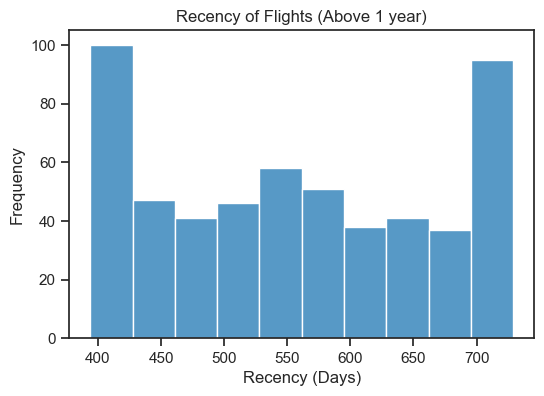

In [402]:
perc_above_365 = (recency > 365).mean() * 100
print(perc_above_365)
plt.figure(figsize=(6,4))
sns.histplot(recency[recency > 365], bins=10)
plt.title("Recency of Flights (Above 1 year)")
plt.xlabel("Recency (Days)")
plt.ylabel("Frequency")
plt.show()

Customers with long recency periods(>>3*Quartile) represent extreme values in the dataset. To limit their impact on clustering while preserving overall patterns, we can apply a ceiling and set all recency values above 365 days to 365

In [403]:
Value_Based_Segmentation_clustering['Recency_Days'] = (
    Value_Based_Segmentation_clustering['Recency_Days']
    .clip(upper=365)
)

### Visualizations after working on outliers

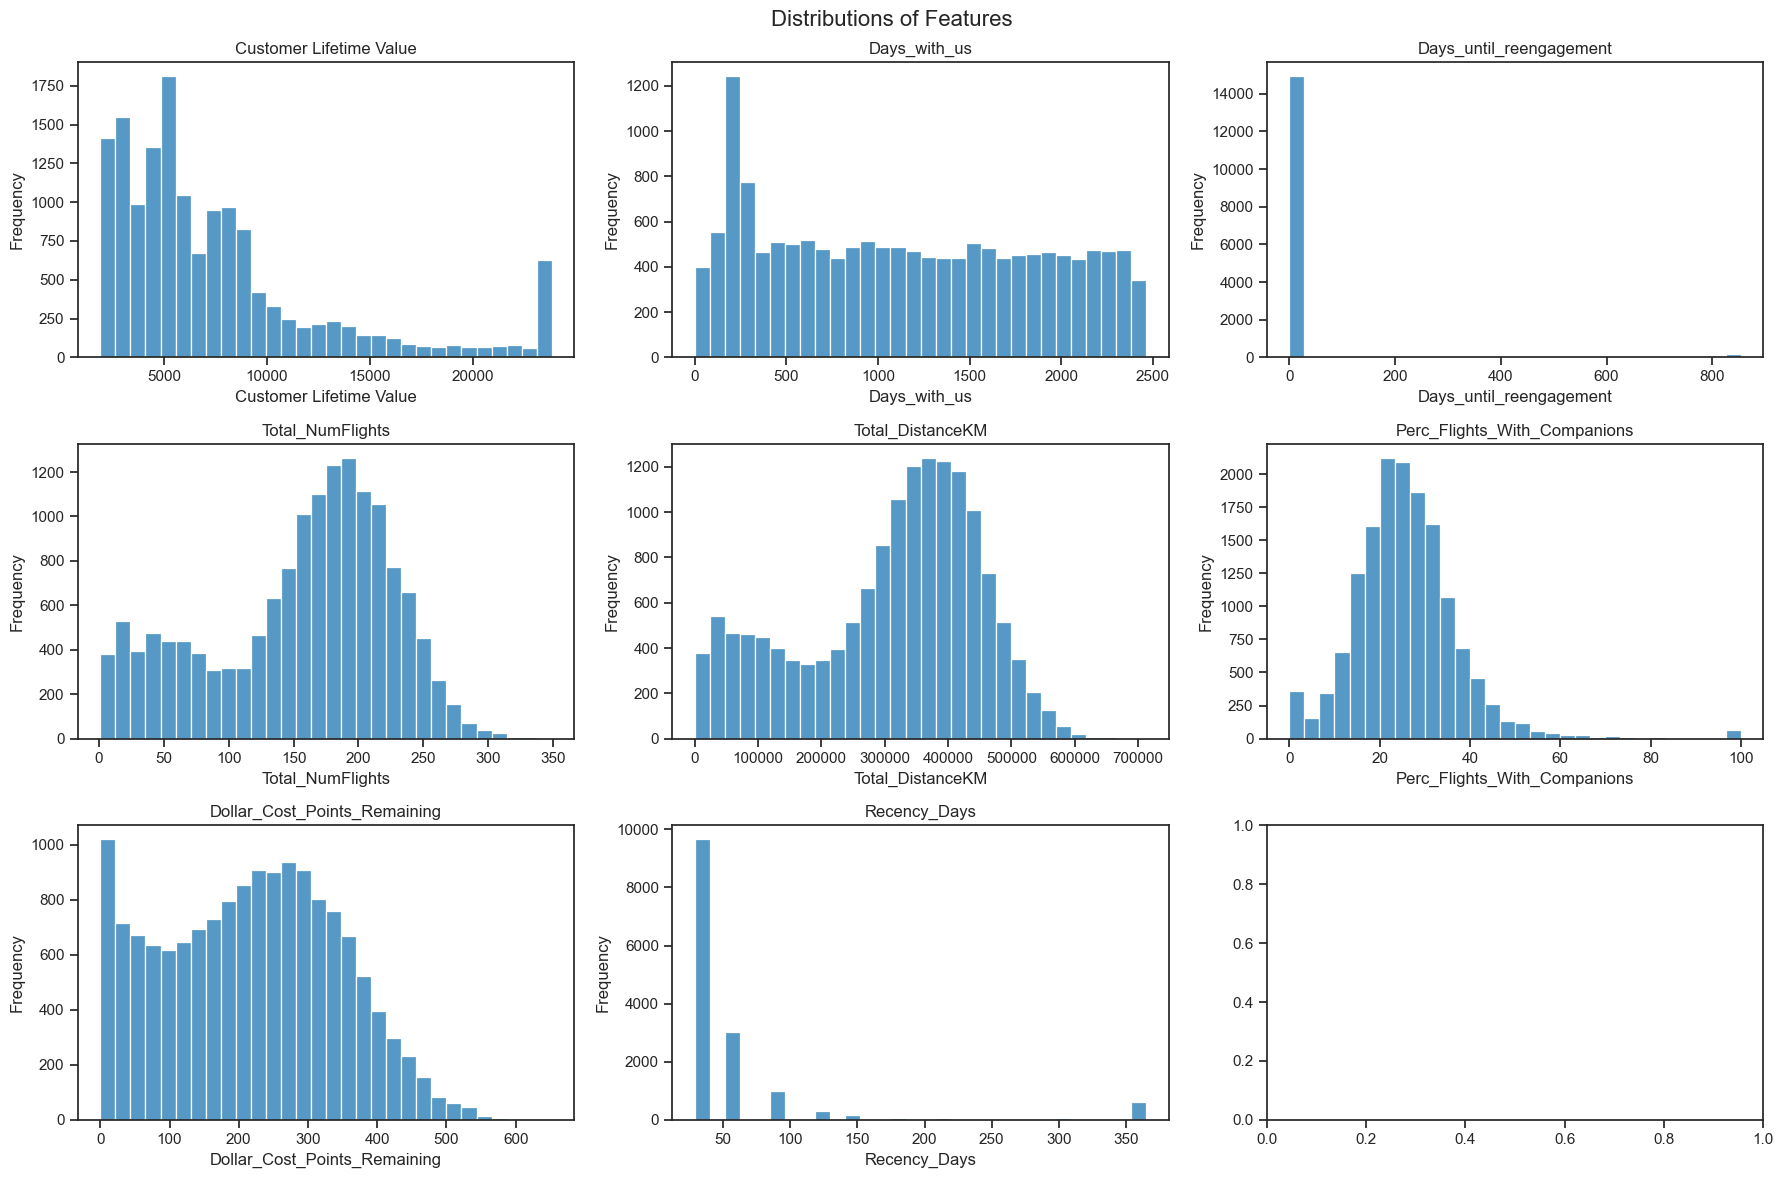

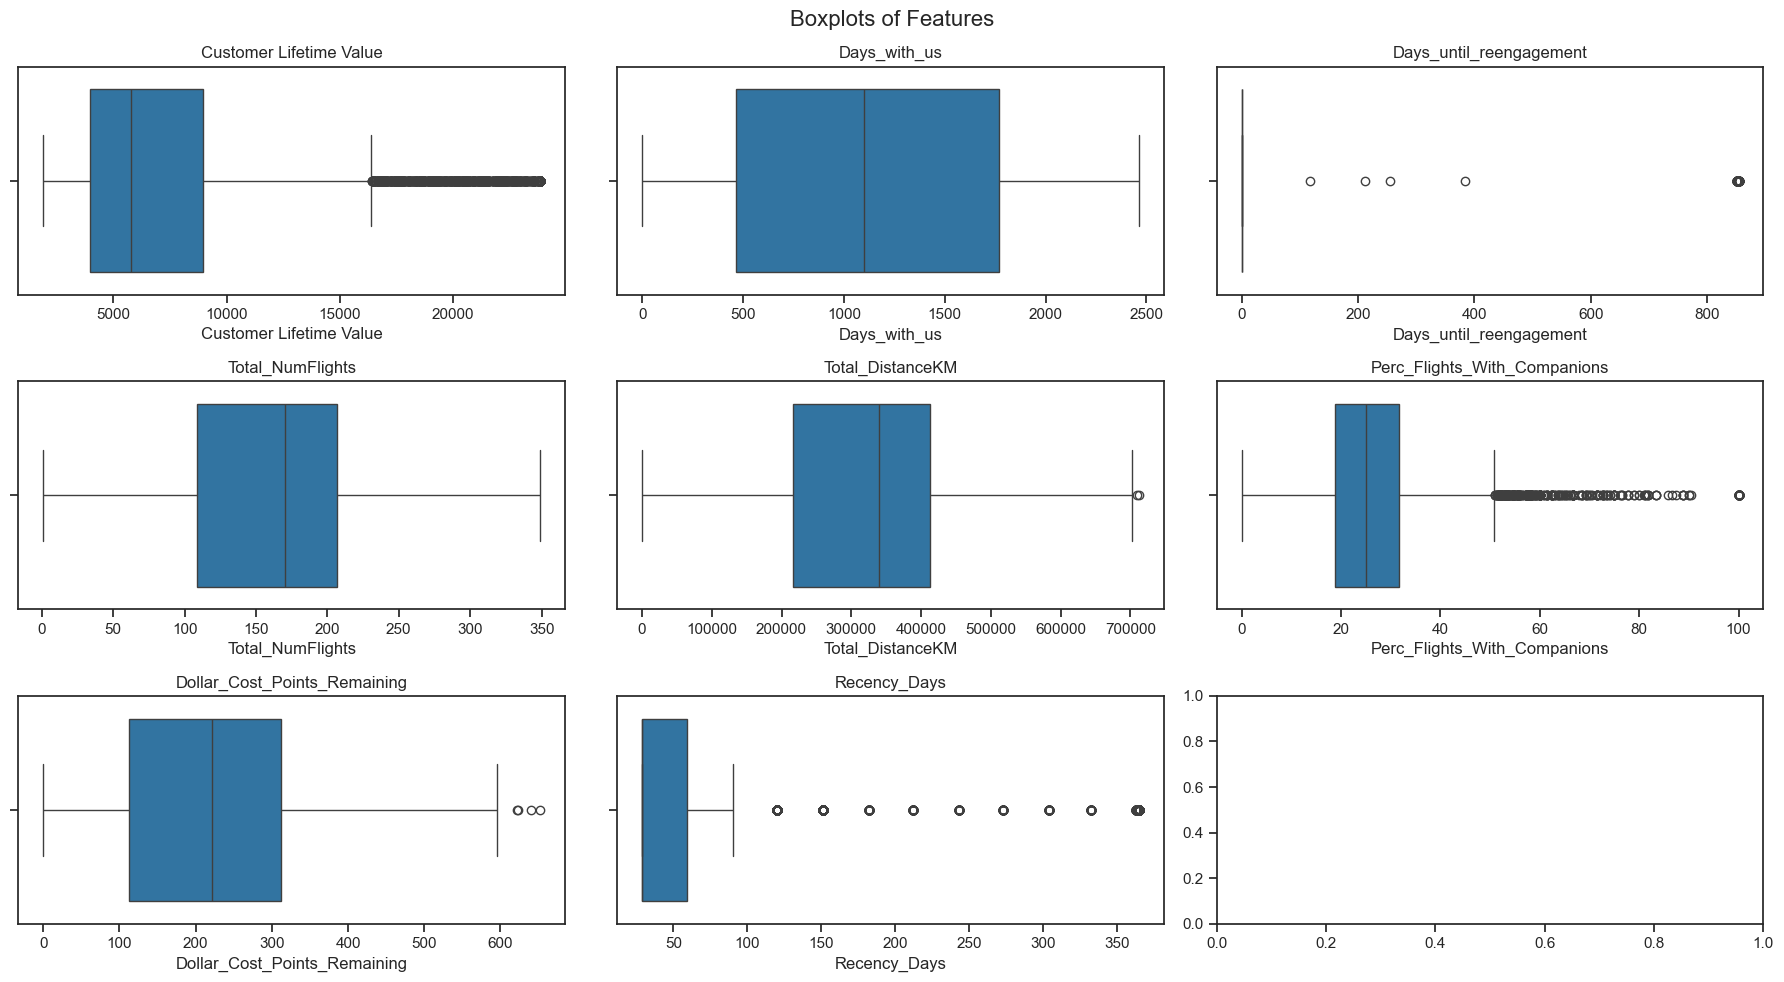

In [404]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.histplot(data, bins=30, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distributions of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.boxplot(x=data, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()


## Scaling 

We are using Robust scaler to each feature except Loyalty# since its our id and later on we will extract it before actually putting to the model so it wont influence our clustering

In [405]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
features_to_scale = [
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

# create a separate dataframe to hold the scaled version (preserve original)
Value_Based_Segmentation_clustering_scaled = Value_Based_Segmentation_clustering.copy()

# scale the selected features and store them in the new dataframe
Value_Based_Segmentation_clustering_scaled[features_to_scale] = scaler.fit_transform(
    Value_Based_Segmentation_clustering[features_to_scale]
)

# optionally inspect
Value_Based_Segmentation_clustering_scaled.head()

,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
Loyalty#,,,,,,,,
480934,-0.388494,-0.038314,0.0,0.214286,0.803876,0.336049,0.701349,0.000000
549612,-0.388399,-0.055172,0.0,1.112245,0.255602,-1.052675,-0.282791,0.000000
429460,-0.388371,0.134100,0.0,-0.510204,-0.561522,0.648336,-0.234241,11.133333
608370,-0.388371,0.800000,0.0,0.265306,0.235653,0.357247,0.004027,0.000000
530508,-0.387760,0.327969,0.0,0.010204,0.136563,0.921320,0.723347,0.000000


In [406]:
Value_Based_Segmentation_clustering_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,15101.0,0.369505,1.079205,-0.778916,-0.363501,0.0,0.636499,3.636499
Days_with_us,15101.0,0.032304,0.553773,-0.842146,-0.485057,0.0,0.514943,1.046743
Days_until_reengagement,15101.0,9.887756,91.081915,0.000000,0.000000,0.0,0.000000,854.000000
Total_NumFlights,15101.0,-0.150731,0.720967,-1.724490,-0.622449,0.0,0.377551,1.826531
Total_DistanceKM,15101.0,-0.157629,0.719596,-1.731946,-0.627599,0.0,0.372401,1.902890
Perc_Flights_With_Companions,15101.0,0.067562,0.929543,-1.945009,-0.479205,0.0,0.520795,5.835028
Dollar_Cost_Points_Remaining,15101.0,-0.026195,0.637974,-1.108912,-0.548547,0.0,0.451453,2.151060
Recency_Days,15101.0,1.056455,2.463675,0.000000,0.000000,0.0,1.000000,11.200000


# Clustering

### Our Final data set for clusting

Now droping Loyalty# for clustering

In [407]:
## Value_Based_Segmentation_clustering_no_transaction_fit = Value_Based_Segmentation_clustering_no_transaction.drop(columns=['Loyalty#'])
## Value_Based_Segmentation_clustering preprocesses but not scaled
## Value_Based_Segmentation_clustering_scaled preprocesses and scaled with Loyalty# as an index
Value_Based_Segmentation_clustering['Final_Cluster'] = 'Unspecified'

classified_data = Value_Based_Segmentation_clustering[
    Value_Based_Segmentation_clustering.Final_Cluster != 'Unspecified'
]
unclassified_data = Value_Based_Segmentation_clustering[
    Value_Based_Segmentation_clustering.Final_Cluster == 'Unspecified'
]
data_for_modelling = (
    Value_Based_Segmentation_clustering_scaled
        .loc[unclassified_data.index]
)
print(data_for_modelling.describe().T)
print(data_for_modelling.head())
print(classified_data.head())
print(unclassified_data.head())
print(Value_Based_Segmentation_clustering_scaled.head())

                                count      mean        std       min       25%  50%       75%         max
Customer Lifetime Value       15101.0  0.369505   1.079205 -0.778916 -0.363501  0.0  0.636499    3.636499
Days_with_us                  15101.0  0.032304   0.553773 -0.842146 -0.485057  0.0  0.514943    1.046743
Days_until_reengagement       15101.0  9.887756  91.081915  0.000000  0.000000  0.0  0.000000  854.000000
Total_NumFlights              15101.0 -0.150731   0.720967 -1.724490 -0.622449  0.0  0.377551    1.826531
Total_DistanceKM              15101.0 -0.157629   0.719596 -1.731946 -0.627599  0.0  0.372401    1.902890
Perc_Flights_With_Companions  15101.0  0.067562   0.929543 -1.945009 -0.479205  0.0  0.520795    5.835028
Dollar_Cost_Points_Remaining  15101.0 -0.026195   0.637974 -1.108912 -0.548547  0.0  0.451453    2.151060
Recency_Days                  15101.0  1.056455   2.463675  0.000000  0.000000  0.0  1.000000   11.200000
          Customer Lifetime Value  Days_with_u

In [408]:
print(data_for_modelling.shape)
print(data_for_modelling.isna().sum())

(15101, 8)
Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64


In [409]:
data_for_modelling.var().sort_values()

Days_with_us                       0.306664
Dollar_Cost_Points_Remaining       0.407010
Total_DistanceKM                   0.517818
Total_NumFlights                   0.519793
Perc_Flights_With_Companions       0.864050
Customer Lifetime Value            1.164684
Recency_Days                       6.069697
Days_until_reengagement         8295.915281
dtype: float64

### Datasets Overview

Different versions of the data are used to clearly separate **model fitting**, **interpretation**, and **final analysis**.

#### `Value_Based_Segmentation_clustering_no_transaction_fit`
Data of the customers who do not have any transactions.
Used to test clustering behavior without transactional information.

---

#### `classified_data`
Customers whose `Final_Cluster` is **already defined**.  
Used for final cluster profiling, interpretation, and reporting.

---

#### `unclassified_data`
Customers whose `Final_Cluster` is `"Unspecified"`.  
This is the dataset used to explore and evaluate clustering solutions.

---

#### `data_for_modelling`
**Scaled numeric data** used to fit clustering algorithms.  
Scaling is applied only for modeling, not for interpretation.

---


# K-Means - Original Data


The first clustering solution we will try is a KMeans, firstly we'll plot the elbow curve to find the optimal number of clusters.

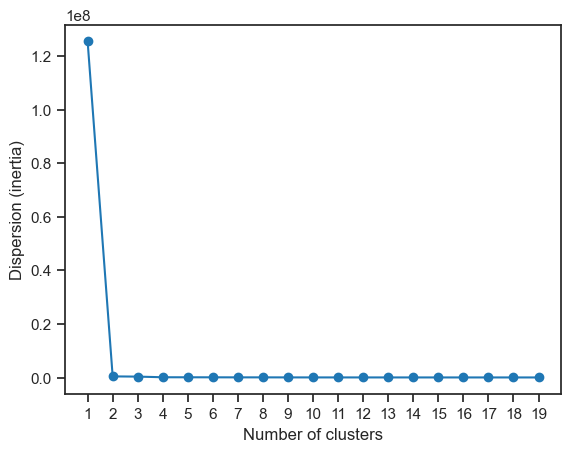

In [410]:
dispersion = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(data_for_modelling)
    dispersion.append(kmeans.inertia_)
plt.plot(range(1, 20), dispersion, marker='o')
plt.xticks(range(1, 20))
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()


In [411]:
means = KMeans(n_clusters=4, random_state=0)
unclassified_data['cluster_kmeans'] = means.fit_predict(data_for_modelling)